In [2]:
%matplotlib inline

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(
    '../../statics/datasets/reviews_New_York_short.csv', 
)

In [3]:
# Podstawowe info o kolumnach i brakujących wartościach
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 815354 entries, 0 to 815353
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       815354 non-null  int64  
 1   rating     815238 non-null  float64
 2   text       815324 non-null  str    
 3   name       815354 non-null  str    
 4   category   815354 non-null  str    
 5   latitude   815354 non-null  float64
 6   longitude  815354 non-null  float64
dtypes: float64(3), int64(1), str(3)
memory usage: 180.3 MB


In [4]:

# brakujące wartości
df.isnull().sum()

time           0
rating       116
text          30
name           0
category       0
latitude       0
longitude      0
dtype: int64

Rozkład ocen:
rating
1.0     28459
2.0     18942
3.0     62899
4.0    164694
5.0    540244
Name: count, dtype: int64

Średnia ocena: 4.43


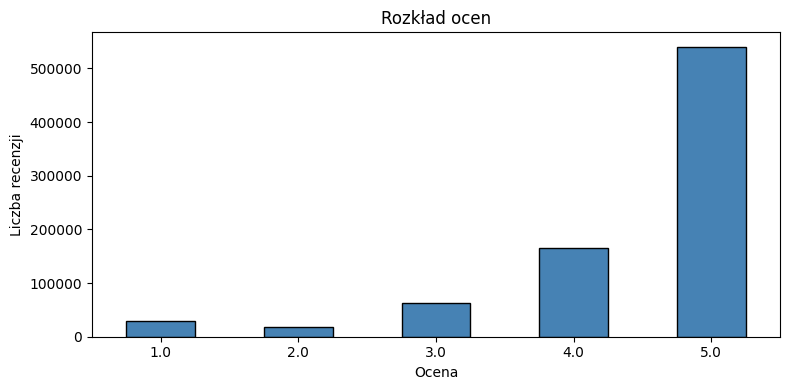

In [5]:
# Rozkład ocen (rating) - kluczowe dla analizy sentymentu
rating_counts = df['rating'].value_counts().sort_index()
print("Rozkład ocen:")
print(rating_counts)
print(f"\nŚrednia ocena: {df['rating'].mean():.2f}")

plt.figure(figsize=(8, 4))
rating_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Rozkład ocen')
plt.xlabel('Ocena')
plt.ylabel('Liczba recenzji')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [6]:
# Analiza tekstu recenzji - długość i puste wartości
df_with_text = df[df['text'].notna()].copy()
df_with_text['text_len'] = df_with_text['text'].str.len()
df_with_text['word_count'] = df_with_text['text'].str.split().str.len()

print(f"Recenzje z tekstem: {len(df_with_text):,} ({100*len(df_with_text)/len(df):.1f}%)")
print(f"Recenzje bez tekstu: {df['text'].isna().sum():,}")
print(f"\nDługość tekstu (znaki): min={df_with_text['text_len'].min()}, max={df_with_text['text_len'].max()}, mediana={df_with_text['text_len'].median():.0f}")
print(f"Liczba słów: min={df_with_text['word_count'].min()}, max={df_with_text['word_count'].max()}, mediana={df_with_text['word_count'].median():.0f}")

Recenzje z tekstem: 815,324 (100.0%)
Recenzje bez tekstu: 30

Długość tekstu (znaki): min=1, max=12530, mediana=59
Liczba słów: min=1, max=1637, mediana=10


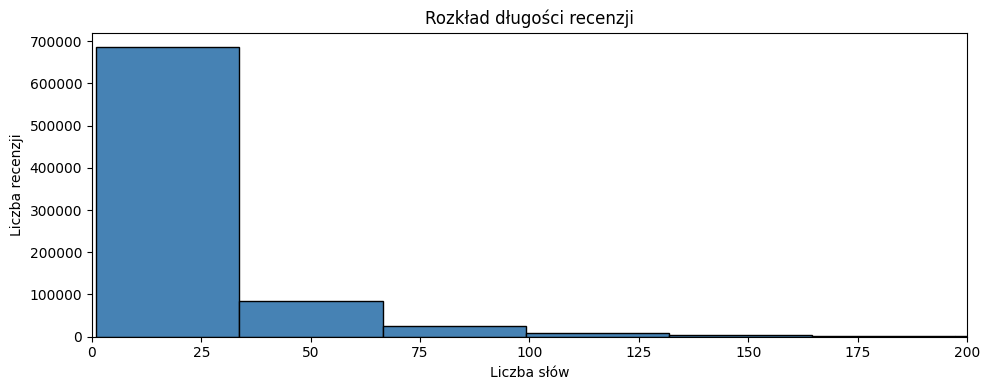

In [7]:
# Histogram długości recenzji (liczba słów)
plt.figure(figsize=(10, 4))
plt.hist(df_with_text['word_count'], bins=50, color='steelblue', edgecolor='black')
plt.xlabel('Liczba słów')
plt.ylabel('Liczba recenzji')
plt.title('Rozkład długości recenzji')
plt.xlim(0, 200)  # Ograniczenie dla czytelności
plt.tight_layout()
plt.show()

Średnia liczba słów wg oceny:
rating
1.0    39.7
2.0    29.8
3.0    22.8
4.0    20.2
5.0    18.2
Name: word_count, dtype: float64


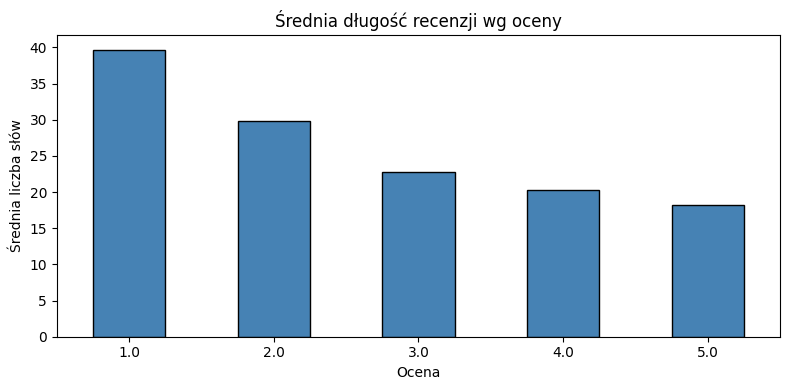

In [8]:
# Średnia długość recenzji vs ocena - czy negatywne recenzje są dłuższe?
avg_words_by_rating = df_with_text.groupby('rating')['word_count'].mean()

print("Średnia liczba słów wg oceny:")
print(avg_words_by_rating.round(1))

plt.figure(figsize=(8, 4))
avg_words_by_rating.plot(kind='bar', color='steelblue', edgecolor='black')

plt.title('Średnia długość recenzji wg oceny')
plt.xlabel('Ocena')
plt.ylabel('Średnia liczba słów')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
# Liczba unikalnych miejsc (gmap_id) i recenzji na miejsce
n_places = df['gmap_id'].nunique()
reviews_per_place = df.groupby('gmap_id').size()

print(f"Liczba unikalnych miejsc: {n_places:,}")
print(f"Recenzji na miejsce: min={reviews_per_place.min()}, max={reviews_per_place.max()}, mediana={reviews_per_place.median():.0f}")

KeyError: 'gmap_id'

Recenzje wg roku:
year
2005         3
2006         3
2008        11
2009        15
2010       120
2011       401
2012      1056
2013      3360
2014      3381
2015      9854
2016     44849
2017    113117
2018    183829
2019    291297
2020    123243
2021     40815
Name: count, dtype: int64


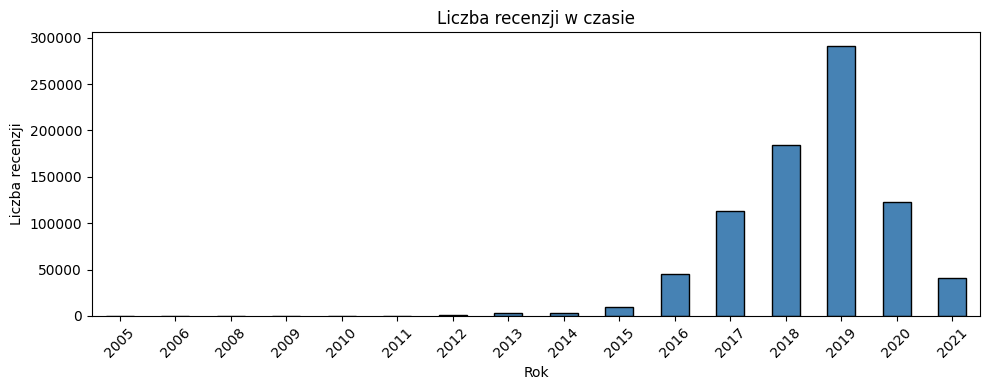

In [10]:
# Rozkład czasowy recenzji
df['datetime'] = pd.to_datetime(df['time'], unit='ms')
df['year'] = df['datetime'].dt.year

yearly_counts = df['year'].value_counts().sort_index()
print("Recenzje wg roku:")
print(yearly_counts)

plt.figure(figsize=(10, 4))
yearly_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Liczba recenzji w czasie')
plt.xlabel('Rok')
plt.ylabel('Liczba recenzji')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Przykładowe recenzje - pozytywne i negatywne
print("=== Przykładowe recenzje pozytywne (5 gwiazdek) ===")
sample_pos = df_with_text[df_with_text['rating'] == 5]['text'].sample(3, random_state=42)
for i, txt in enumerate(sample_pos, 1):
    print(f"{i}. {txt[:200]}...")

print("\n=== Przykładowe recenzje negatywne (1 gwiazdka) ===")
sample_neg = df_with_text[df_with_text['rating'] == 1]['text'].sample(3, random_state=42)
for i, txt in enumerate(sample_neg, 1):
    print(f"{i}. {txt[:200]}...")

=== Przykładowe recenzje pozytywne (5 gwiazdek) ===
1. (Translated by Google) Well-kept public gardens and cordoned off by a net, with spaces to lie down and rest. From here you take tickets and in a short time you get to the statue of liberty  (Original)...
2. Best tacos ever at La taqueria no. 1....
3. A very nice pl...

=== Przykładowe recenzje negatywne (1 gwiazdka) ===
1. The elevator sucks...
2. Scary place to go! 2 fights broke out while I was there...
3. (Translated by Google) A line like an hour and then they came out to say that we could not pass  (Original) Una fila como de una hora y despues salueron a decir q no podiamos pasar...
